# Forward propagation in neural networks — Simplified math and code version
https://towardsdatascience.com/forward-propagation-in-neural-networks-simplified-math-and-code-version-bbcfef6f9250

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors
from sklearn.datasets import make_moons

In [2]:
np.random.seed(0)
data, labels = make_moons(n_samples=200,noise = 0.04,random_state=0)
print(data.shape, labels.shape)

(200, 2) (200,)


In [3]:
data

array([[ 0.82169506,  0.52544392],
       [ 1.61599907, -0.36301579],
       [-0.01210158,  0.2749205 ],
       [-1.01734763, -0.05400628],
       [ 1.76644595, -0.16511651],
       [ 1.87721964, -0.03664307],
       [ 0.97734018,  0.19959527],
       [ 0.88822262, -0.49026157],
       [ 0.90459484,  0.36743458],
       [ 1.10896179, -0.52705404],
       [-0.36241753,  0.84915105],
       [ 0.25732436, -0.23339225],
       [ 1.81800458, -0.11811907],
       [ 1.20157537, -0.42345038],
       [-0.823671  ,  0.6272934 ],
       [ 0.97961062,  0.21086881],
       [ 0.5327774 ,  0.88213966],
       [ 0.36241342, -0.303726  ],
       [ 0.358721  ,  0.89509298],
       [-0.76196411,  0.80056981],
       [ 1.91549638,  0.01247382],
       [ 0.86031081, -0.47919001],
       [ 0.18838852,  0.99534316],
       [ 1.29100815, -0.38754914],
       [-0.28819468,  1.00930778],
       [ 0.24445044, -0.09437629],
       [ 1.8409642 , -0.09677097],
       [ 1.88784026,  0.04999318],
       [ 0.17944871,

In [4]:
labels

array([0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1,
       1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 1], dtype=int64)

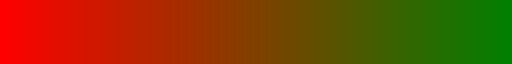

In [5]:
color_map = matplotlib.colors.LinearSegmentedColormap.from_list("", ["red", "green"])
color_map

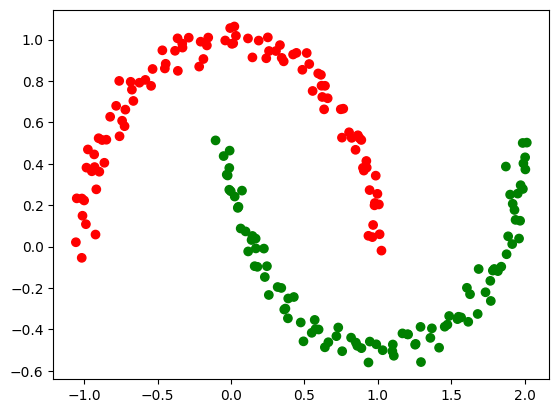

In [6]:
plt.scatter(data[:,0], data[:,1], c=labels, cmap=color_map)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
#Splitting the data into training and testing data
X_train, X_val, Y_train, Y_val = train_test_split(data, labels, stratify=labels, random_state=0)
print(X_train.shape, X_val.shape)

(150, 2) (50, 2)


In [8]:
class FeedForwardNetwork:
 
 def __init__(self):
     np.random.seed(0)
     self.w1 = np.random.randn()
     self.w2 = np.random.randn()
     self.w3 = np.random.randn()
     self.w4 = np.random.randn()
     self.w5 = np.random.randn()
     self.w6 = np.random.randn()
     self.b1 = 0
     self.b2 = 0
     self.b3 = 0
 
 def sigmoid(self, x):
     return 1.0/(1.0 + np.exp(-x))
 
 def forward_pass(self, x):
     self.x1, self.x2 = x
     self.a1 = self.w1*self.x1 + self.w2*self.x2 + self.b1
     self.h1 = self.sigmoid(self.a1)
     self.a2 = self.w3*self.x1 + self.w4*self.x2 + self.b2
     self.h2 = self.sigmoid(self.a2)
     self.a3 = self.w5*self.h1 + self.w6*self.h2 + self.b3
     self.h3 = self.sigmoid(self.a3)
     forward_matrix = np.array([[0,0,0,0,self.h3,0,0,0], 
                      [0,0,(self.w5*self.h1),        (self.w6*self.h2),self.b3,self.a3,0,0],
                      [0,0,0,self.h1,0,0,0,self.h2],
                      [(self.w1*self.x1), (self.w2*self.x2),         self.b1, self.a1,(self.w3*self.x1),(self.w4*self.x2), self.b2,  self.a2]])
     forward_matrices.append(forward_matrix)
     return self.h3

In [14]:
forward_matrices = []
ffn = FeedForwardNetwork()
for x, y in zip(X_train, Y_train):
   h = ffn.forward_pass(x)
   print(x, h, y)

[ 0.88822262 -0.49026157] 0.7420206980277352 1
[0.86412591 0.53793474] 0.6731972373400515 0
[-0.68385079  0.79629916] 0.45229079011479567 0
[ 0.2237945  -0.00935363] 0.6404196436280386 1
[ 1.03294998 -0.50013762] 0.749830215687175 1
[0.96788647 0.1047059 ] 0.6990964611997541 0
[-0.20701017  0.99008524] 0.5214457008563742 0
[0.64003461 0.77696614] 0.6493727951518926 0
[-0.10550411  0.51323228] 0.5546363190435729 1
[1.98699645 0.50084197] 0.708671613065308 1
[ 0.38737522 -0.34616262] 0.6876263264838771 1
[-0.86317465  0.40513448] 0.4693440620620247 0
[1.88784026 0.04999318] 0.7206492950705203 1
[ 1.54266055 -0.35001306] 0.7460506259263316 1
[-0.36434004  1.00620552] 0.49307515652542966 0
[-0.28819468  1.00930778] 0.5065862719905307 0
[ 0.17944871 -0.09746253] 0.6420678758705604 1
[ 1.68027603 -0.32512071] 0.7438137403987708 1
[2.01492765 0.50250741] 0.7088492470236908 1
[-0.7828386   0.68018712] 0.44964169534026727 0
[ 1.41738167 -0.48802142] 0.7573655281353615 1
[-0.7596498   0.53317152

C:\Users\jyang\AppData\Local\Temp\ipykernel_24792\2298934018.py:10: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
C:\Users\jyang\AppData\Local\Temp\ipykernel_24792\2298934018.py:10: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
C:\Users\jyang\AppData\Local\Temp\ipykernel_24792\2298934018.py:10: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be removed in 3.10. Use buffer_rgba instead.
  image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
C:\Users\jyang\AppData\Local\Temp\ipykernel_24792\2298934018.py:10: MatplotlibDeprecationWarning: The tostring_rgb function was deprecated in Matplotlib 3.8 and will be 

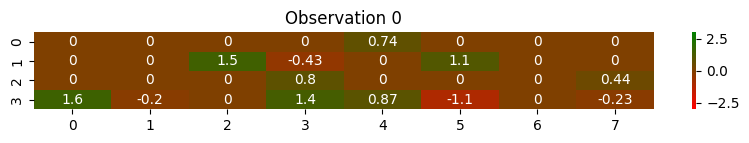

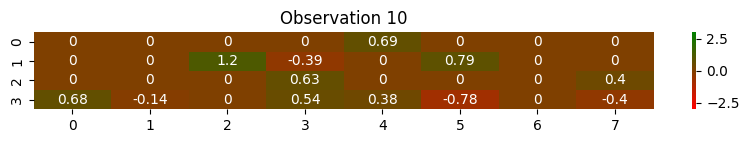

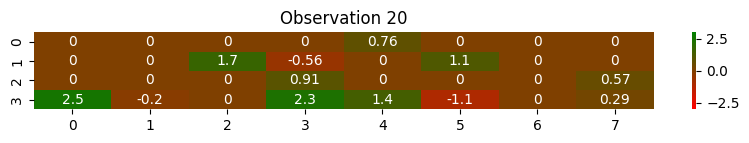

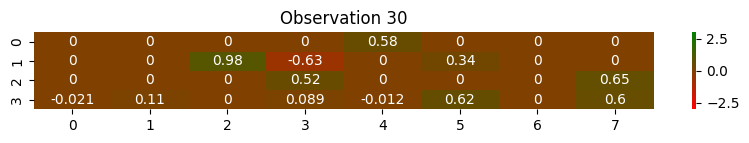

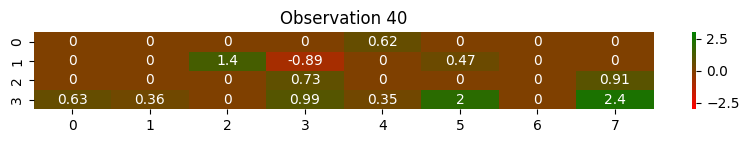

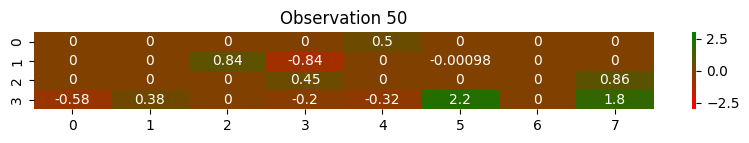

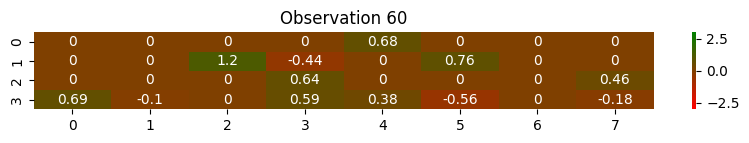

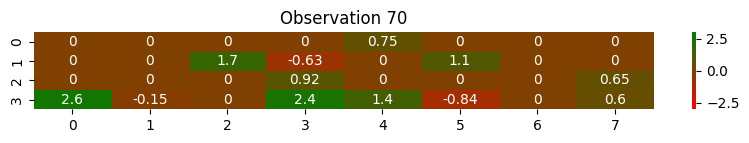

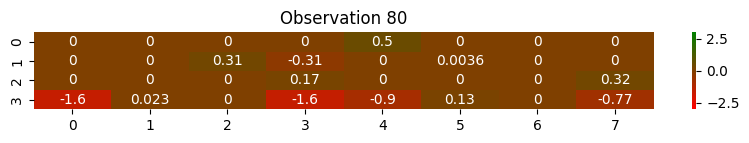

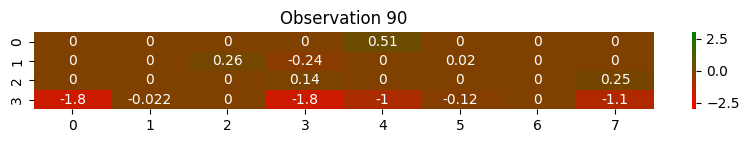

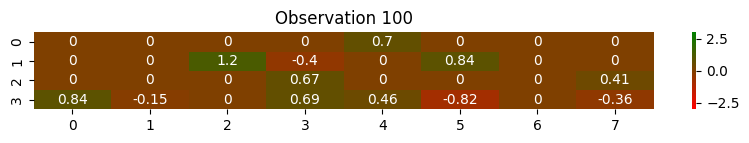

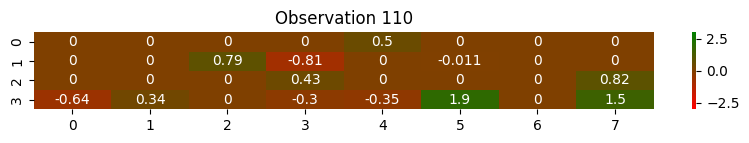

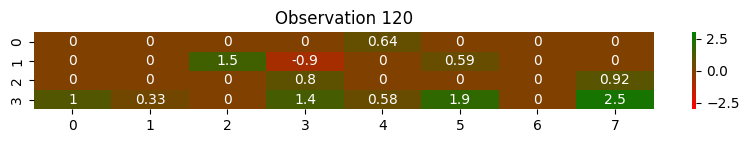

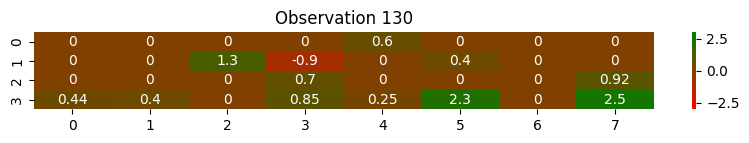

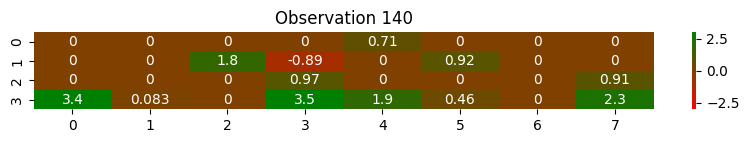

In [12]:
import seaborn as sns
import imageio
from IPython.display import HTML

def plot_heat_map(observation):
    fig = plt.figure(figsize=(10, 1))
    sns.heatmap(forward_matrices[observation], annot=True,     cmap=color_map, vmin=-3, vmax=3)
    plt.title('Observation ' + str(observation))
    fig.canvas.draw()
    image = np.frombuffer(fig.canvas.tostring_rgb(), dtype='uint8')
    image = image.reshape(fig.canvas.get_width_height()[::-1] +             (3,))
    return image

imageio.mimsave('./forwardpropagation_viz.gif', [plot_heat_map(i) for i in range(0,len(forward_matrices),len(forward_matrices)//15)], fps=1)